# PCA through Singular Value Decomposition

In [1]:
import numpy as np

# Defined 3 points in 2D-space:
X = np.array([[2, 1, 0],
              [4, 3, 0]])

# Calculate the covariance matrix:
# center the data (very important for covariance / PCA idea)
mu = np.mean(X, axis=1, keepdims=True)   # mean of each row (x and y)
Xc = X - mu                               # centered data

# covariance matrix (2x2)
# (divide by N-1 like the usual sample covariance)
N = X.shape[1]
R = (Xc @ Xc.T) / (N - 1)

# Calculate the SVD decomposition and new basis vectors:
[U, D, V] = np.linalg.svd(R)  # call SVD decomposition
u1 = U[:, 0]  # new basis vectors
u2 = U[:, 1]

# Calculate the coordinates in new orthonormal basis:
# projection of centered points onto the new axes
Xi1 = u1.T @ Xc   # coordinates along u1 (shape: (3,))
Xi2 = u2.T @ Xc   # coordinates along u2 (shape: (3,))

# Calculate the approximation of the original from new basis
# Approx with only the first component (rank-1 approximation)
X_approx1 = (u1[:, None] @ Xi1[None, :]) + mu

# (optional) exact reconstruction with both components (should match original)
X_recon = (u1[:, None] @ Xi1[None, :]) + (u2[:, None] @ Xi2[None, :]) + mu

#print(Xi1[:,None]) # add second dimention to array and test it

# Check that you got the original
print("Original X:\n", X)
print("\nCovariance matrix R:\n", R)

print("\nNew basis vectors:")
print("u1 =", u1)
print("u2 =", u2)

print("\nCoordinates in new basis:")
print("Xi1 =", Xi1)
print("Xi2 =", Xi2)

print("\nApproximation using only u1 (rank-1):\n", X_approx1)

print("\nReconstruction using u1 and u2 (should be X):\n", X_recon)

print("\nIs reconstruction close to original? ->", np.allclose(X, X_recon))
print("Max absolute error =", np.max(np.abs(X - X_recon)))

Original X:
 [[2 1 0]
 [4 3 0]]

Covariance matrix R:
 [[1.         2.        ]
 [2.         4.33333333]]

New basis vectors:
u1 = [-0.4241554  -0.90558942]
u2 = [-0.90558942  0.4241554 ]

Coordinates in new basis:
Xi1 = [-1.9334711  -0.60372628  2.53719738]
Xi2 = [-0.19866376  0.28277026 -0.0841065 ]

Approximation using only u1 (rank-1):
 [[ 1.8200922   1.25607376 -0.07616596]
 [ 4.08426431  2.88006147  0.03567423]]

Reconstruction using u1 and u2 (should be X):
 [[ 2.00000000e+00  1.00000000e+00  1.11022302e-16]
 [ 4.00000000e+00  3.00000000e+00 -4.44089210e-16]]

Is reconstruction close to original? -> True
Max absolute error = 4.440892098500626e-16


# PCA on Iris data

In [2]:
# Load Iris dataset as in the last PC lab:
from sklearn.datasets import load_iris
iris=load_iris()
iris.feature_names
print(iris.feature_names)
print(iris.data[0:5,:])
print(iris.target[:])

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


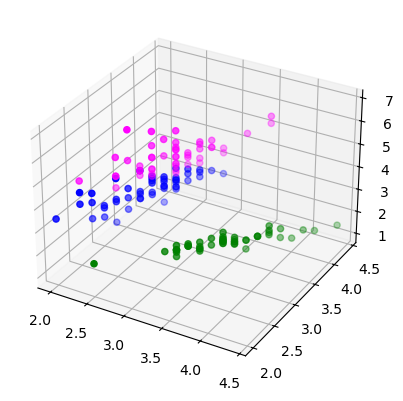

In [5]:
# We have 4 dimensions of data, plot the first three colums in 3D
X=iris.data
y=iris.target
import matplotlib.pyplot as plt
axes1=plt.axes(projection='3d')
axes1.scatter3D(X[y==0,1],X[y==0,1],X[y==0,2],color='green')
axes1.scatter3D(X[y==1,1],X[y==1,1],X[y==1,2],color='blue')
axes1.scatter3D(X[y==2,1],X[y==2,1],X[y==2,2],color='magenta')
plt.show()


[[ 1.00671141 -0.11835884  0.87760447  0.82343066]
 [-0.11835884  1.00671141 -0.43131554 -0.36858315]
 [ 0.87760447 -0.43131554  1.00671141  0.96932762]
 [ 0.82343066 -0.36858315  0.96932762  1.00671141]]


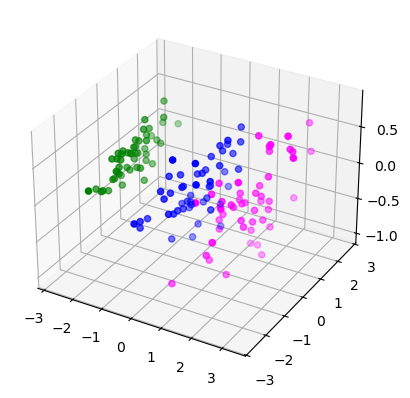

In [7]:
# Pre-processing is an important step, you can try either StandardScaler (zero mean, unit variance of features)
# or MinMaxScaler (to interval from 0 to 1)
from sklearn import preprocessing
from sklearn import decomposition
from sklearn.preprocessing import StandardScaler
Xscaler = StandardScaler()
Xpp=Xscaler.fit_transform(X)

# define PCA object (three components), fit and transform the data
pca = decomposition.PCA(n_components=3)
pca.fit(Xpp)
Xpca = pca.transform(Xpp)
print(pca.get_covariance())
# you can plot the transformed feature space in 3D:
axes2=plt.axes(projection='3d')
axes2.scatter3D(Xpca[y==0,0],Xpca[y==0,1],Xpca[y==0,2],color='green')
axes2.scatter3D(Xpca[y==1,0],Xpca[y==1,1],Xpca[y==1,2],color='blue')
axes2.scatter3D(Xpca[y==2,0],Xpca[y==2,1],Xpca[y==2,2],color='magenta')
plt.show()


In [8]:
# Compute pca.explained_variance_ and pca.explained_cariance_ratio_values
pca.explained_variance_

array([2.93808505, 0.9201649 , 0.14774182])

In [9]:
pca.explained_variance_ratio_

array([0.72962445, 0.22850762, 0.03668922])

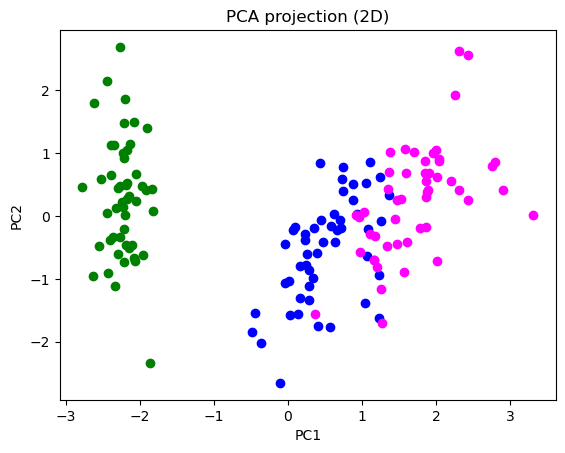

In [11]:
# Plot the principal components in 2D, mark different targets in color
plt.figure()

plt.scatter(Xpca[y==0,0], Xpca[y==0,1], color='green')
plt.scatter(Xpca[y==1,0], Xpca[y==1,1], color='blue')
plt.scatter(Xpca[y==2,0], Xpca[y==2,1], color='magenta')

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA projection (2D)")
plt.show()

# KNN classifier

[[16  0  0]
 [ 0 17  1]
 [ 0  0 11]]


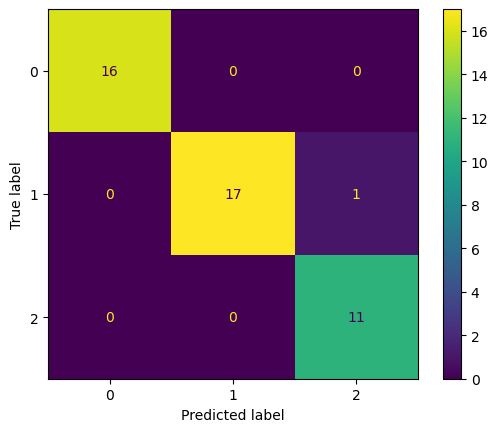

In [13]:
# Import train_test_split as in last PC lab, split X (original) into train and test, train KNN classifier on full 4-dimensional X

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

# X original (4 features) and labels
X = iris.data
y = iris.target

# split into train and test
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.3, random_state=0)

knn1 = KNeighborsClassifier(n_neighbors=3)
knn1.fit(Xtrain, ytrain)

Ypred = knn1.predict(Xtest)

# Import and show confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

print(confusion_matrix(ytest, Ypred))
ConfusionMatrixDisplay.from_predictions(ytest, Ypred)
plt.show()


[[16  0  0]
 [ 0 15  3]
 [ 0  1 10]]


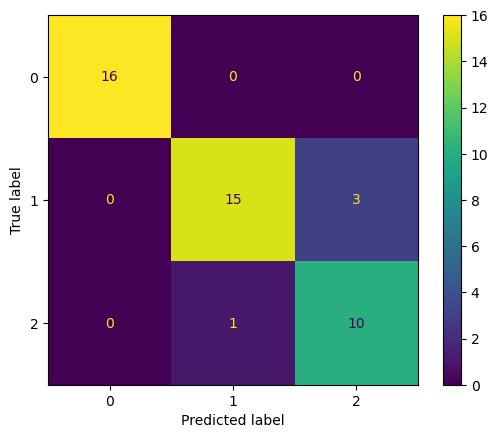

Accuracy with PCA (2 components): 0.9111111111111111


In [15]:
# Now do the same (data set split, KNN, confusion matrix), but for PCA-transformed data (1st two principal components, i.e., first two columns). 
# Compare the results with full dataset



# Take only first two PCA components
Xpca2 = Xpca[:, 0:2]

# Split into train and test
Xtrain_pca, Xtest_pca, ytrain_pca, ytest_pca = train_test_split(
    Xpca2, y, test_size=0.3, random_state=0
)

# Train KNN
knn2 = KNeighborsClassifier(n_neighbors=3)
knn2.fit(Xtrain_pca, ytrain_pca)

# Predict
Ypred_pca = knn2.predict(Xtest_pca)

# Confusion matrix
print(confusion_matrix(ytest_pca, Ypred_pca))
ConfusionMatrixDisplay.from_predictions(ytest_pca, Ypred_pca)
plt.show()

# Accuracy
from sklearn.metrics import accuracy_score
print("Accuracy with PCA (2 components):", accuracy_score(ytest_pca, Ypred_pca))

[[16  0  0]
 [ 1  9  8]
 [ 0  3  8]]


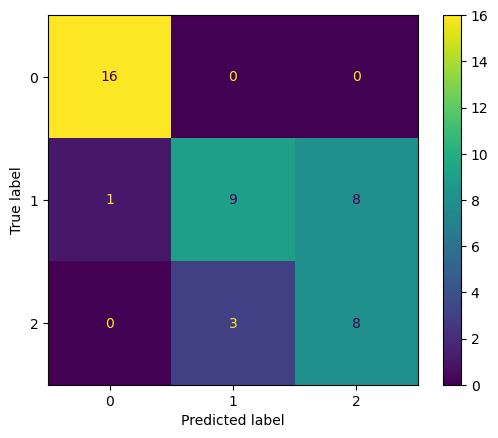

Accuracy with original 2 features: 0.7333333333333333


In [16]:
# Now do the same, but use only 2-dimensional data of original X (first two columns)

# Take only first two original features
X2 = X[:, 0:2]

# Split into train and test
Xtrain2, Xtest2, ytrain2, ytest2 = train_test_split(
    X2, y, test_size=0.3, random_state=0
)

# Train KNN
knn3 = KNeighborsClassifier(n_neighbors=3)
knn3.fit(Xtrain2, ytrain2)

# Predict
Ypred2 = knn3.predict(Xtest2)

# Confusion matrix
print(confusion_matrix(ytest2, Ypred2))
ConfusionMatrixDisplay.from_predictions(ytest2, Ypred2)
plt.show()

# Accuracy
print("Accuracy with original 2 features:", accuracy_score(ytest2, Ypred2))

This shows that dimensionality reduction simplifies the dataset but may slightly reduce classification performance.

[[16  0  0]
 [ 1  9  8]
 [ 0  3  8]]


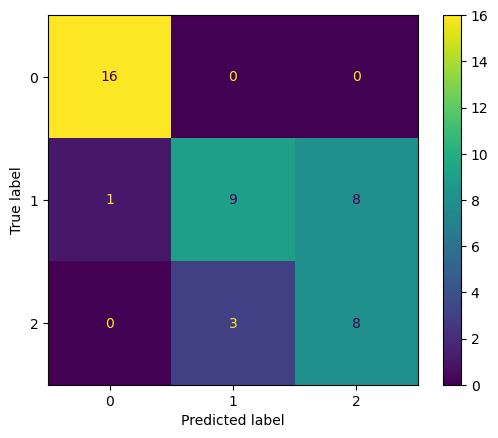

Accuracy with original 2 features: 0.7333333333333333


In [16]:
# Now do the same, but use only 2-dimensional data of original X (first two columns)

# Take only first two original features
X2 = X[:, 0:2]

# Split into train and test
Xtrain2, Xtest2, ytrain2, ytest2 = train_test_split(
    X2, y, test_size=0.3, random_state=0
)

# Train KNN
knn3 = KNeighborsClassifier(n_neighbors=3)
knn3.fit(Xtrain2, ytrain2)

# Predict
Ypred2 = knn3.predict(Xtest2)

# Confusion matrix
print(confusion_matrix(ytest2, Ypred2))
ConfusionMatrixDisplay.from_predictions(ytest2, Ypred2)
plt.show()

# Accuracy
print("Accuracy with original 2 features:", accuracy_score(ytest2, Ypred2))

Using only the first two original features significantly reduces the classification performance (accuracy ≈ 73%).
This shows that these two features do not contain enough discriminative information to separate the classes properly.